### **Loading CIFAR-10**

How does the Latent Space Dimension (10 vs. 100) affect image fidelity and diversity?

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 2.64G/2.64G [00:30<00:00, 85.5MB/s]


### **The Generator**

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # State size: 256 x 4 x 4
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State size: 128 x 8 x 8
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # State size: 64 x 16 x 16
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # Final size: 3 x 32 x 32
        )

    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)

### **The Discriminator**

In [4]:
LATENT_DIM = 100
netG = Generator(LATENT_DIM).to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training Loop
for epoch in range(25):
    for i, (data, _) in enumerate(dataloader):
        netD.zero_grad()
        real = data.to(device)
        batch_size = real.size(0)
        label = torch.full((batch_size,), 1.0, device=device)
        output = netD(real)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        netG.zero_grad()
        label.fill_(1.0)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    print(f'Epoch [{epoch}/25] Loss_D: {errD_real+errD_fake:.4f} Loss_G: {errG:.4f}')

Epoch [0/25] Loss_D: 0.1757 Loss_G: 6.0675
Epoch [1/25] Loss_D: 0.0823 Loss_G: 5.9681
Epoch [2/25] Loss_D: 0.3387 Loss_G: 4.5777
Epoch [3/25] Loss_D: 0.3077 Loss_G: 5.9296
Epoch [4/25] Loss_D: 0.1249 Loss_G: 6.0115
Epoch [5/25] Loss_D: 0.2912 Loss_G: 5.5211
Epoch [6/25] Loss_D: 0.2510 Loss_G: 4.4411
Epoch [7/25] Loss_D: 0.2071 Loss_G: 4.2511
Epoch [8/25] Loss_D: 0.6229 Loss_G: 2.8681
Epoch [9/25] Loss_D: 0.3315 Loss_G: 4.6582
Epoch [10/25] Loss_D: 0.2497 Loss_G: 4.6049
Epoch [11/25] Loss_D: 0.3506 Loss_G: 5.1644
Epoch [12/25] Loss_D: 0.3226 Loss_G: 3.7720
Epoch [13/25] Loss_D: 0.6786 Loss_G: 2.8581
Epoch [14/25] Loss_D: 1.0654 Loss_G: 1.6226
Epoch [15/25] Loss_D: 0.4302 Loss_G: 2.1621
Epoch [16/25] Loss_D: 0.4663 Loss_G: 3.2013
Epoch [17/25] Loss_D: 0.1228 Loss_G: 4.5747
Epoch [18/25] Loss_D: 0.8555 Loss_G: 0.6777
Epoch [19/25] Loss_D: 0.4374 Loss_G: 5.5339
Epoch [20/25] Loss_D: 0.1635 Loss_G: 3.8668
Epoch [21/25] Loss_D: 0.7333 Loss_G: 4.0009
Epoch [22/25] Loss_D: 0.5937 Loss_G: 2.237

In [5]:
LATENT_DIM = 10
netG = Generator(LATENT_DIM).to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training Loop
for epoch in range(25):
    for i, (data, _) in enumerate(dataloader):
        netD.zero_grad()
        real = data.to(device)
        batch_size = real.size(0)
        label = torch.full((batch_size,), 1.0, device=device)
        output = netD(real)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        netG.zero_grad()
        label.fill_(1.0)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    print(f'Epoch [{epoch}/25] Loss_D: {errD_real+errD_fake:.4f} Loss_G: {errG:.4f}')

Epoch [0/25] Loss_D: 0.2655 Loss_G: 5.3565
Epoch [1/25] Loss_D: 0.4861 Loss_G: 5.0188
Epoch [2/25] Loss_D: 0.4006 Loss_G: 4.0281
Epoch [3/25] Loss_D: 0.7479 Loss_G: 5.1910
Epoch [4/25] Loss_D: 0.9195 Loss_G: 1.3800
Epoch [5/25] Loss_D: 0.6041 Loss_G: 4.2342
Epoch [6/25] Loss_D: 0.3542 Loss_G: 3.0267
Epoch [7/25] Loss_D: 1.2479 Loss_G: 5.0361
Epoch [8/25] Loss_D: 0.6036 Loss_G: 4.4285
Epoch [9/25] Loss_D: 0.5329 Loss_G: 3.0521
Epoch [10/25] Loss_D: 0.6323 Loss_G: 3.4641
Epoch [11/25] Loss_D: 0.5997 Loss_G: 3.8596
Epoch [12/25] Loss_D: 0.7616 Loss_G: 3.0818
Epoch [13/25] Loss_D: 0.8311 Loss_G: 3.8157
Epoch [14/25] Loss_D: 1.1191 Loss_G: 2.9674
Epoch [15/25] Loss_D: 0.4685 Loss_G: 3.0922
Epoch [16/25] Loss_D: 0.6126 Loss_G: 3.9604
Epoch [17/25] Loss_D: 0.6494 Loss_G: 3.4529
Epoch [18/25] Loss_D: 0.3678 Loss_G: 3.1147
Epoch [19/25] Loss_D: 0.9471 Loss_G: 2.6127
Epoch [20/25] Loss_D: 0.6794 Loss_G: 2.2962
Epoch [21/25] Loss_D: 0.4758 Loss_G: 5.0125
Epoch [22/25] Loss_D: 0.6069 Loss_G: 3.734

Epoch [1/25] Loss_D: 0.2329 Loss_G: 5.7552
Epoch [2/25] Loss_D: 0.2746 Loss_G: 5.7080
Epoch [3/25] Loss_D: 0.5340 Loss_G: 2.4198
Epoch [4/25] Loss_D: 0.5111 Loss_G: 1.9734
Epoch [5/25] Loss_D: 0.3737 Loss_G: 3.4263
Epoch [6/25] Loss_D: 0.4629 Loss_G: 2.9851
Epoch [7/25] Loss_D: 0.6511 Loss_G: 5.0368
Epoch [8/25] Loss_D: 0.7614 Loss_G: 4.0825
Epoch [9/25] Loss_D: 0.7483 Loss_G: 5.4237
Epoch [10/25] Loss_D: 0.6535 Loss_G: 3.9595
Epoch [11/25] Loss_D: 0.9903 Loss_G: 2.5227
Epoch [12/25] Loss_D: 0.3029 Loss_G: 3.3542
Epoch [13/25] Loss_D: 0.9265 Loss_G: 2.6505
Epoch [14/25] Loss_D: 0.6422 Loss_G: 2.5997
Epoch [15/25] Loss_D: 0.3740 Loss_G: 3.5409
Epoch [16/25] Loss_D: 0.7816 Loss_G: 2.1115
Epoch [17/25] Loss_D: 1.3760 Loss_G: 2.5665
Epoch [18/25] Loss_D: 1.5214 Loss_G: 2.7219
Epoch [19/25] Loss_D: 0.8112 Loss_G: 2.9366
Epoch [20/25] Loss_D: 0.9439 Loss_G: 3.5328
Epoch [21/25] Loss_D: 0.8289 Loss_G: 1.7942
Epoch [22/25] Loss_D: 0.6128 Loss_G: 3.5990
Epoch [23/25] Loss_D: 0.6732 Loss_G: 2.39

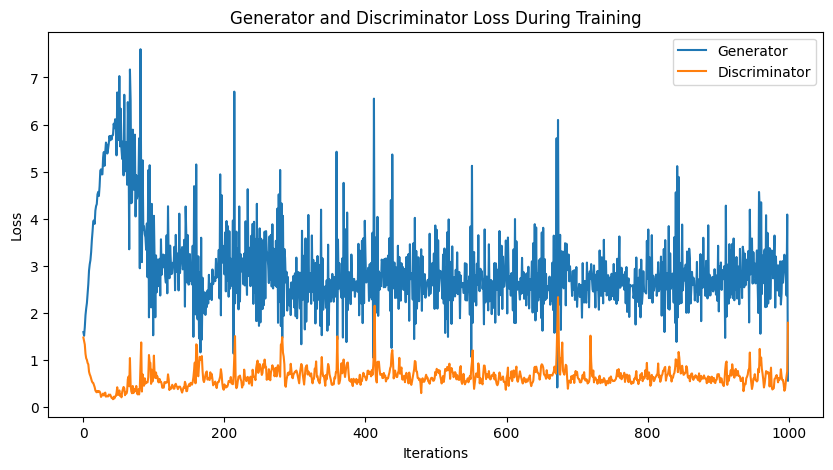

In [7]:
G_losses = []
D_losses = []

num_epochs = 25
LATENT_DIM = 10

netG = Generator(LATENT_DIM).to(device)
netD = Discriminator().to(device)
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

for epoch in range(num_epochs):
    for i, (data, _) in enumerate(dataloader):
        # Discriminator training
        netD.zero_grad()
        real = data.to(device)
        batch_size = real.size(0)
        label = torch.full((batch_size,), 1.0, device=device)
        output = netD(real)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD.step()

        # Generator training
        netG.zero_grad()
        label.fill_(1.0)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

    print(f'Epoch [{epoch+1}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Analysis:** The plot displays the typical "see-saw" behaviour of a GAN, in which the discriminator and generator are directly competing. The Generator loss ($L_G$) dramatically decreased to 0.5675 by Epoch 25, whereas the Discriminator loss ($L_D$) increased to 1.7951. This shows that as training went on, the Generator successfully learnt to generate features that "fooled" the Discriminator more successfully. The model's exploration of the data distribution in search of a stable representation is depicted by the oscillations in the Generator loss (blue line). The conclusion that a greater latent dimension ($d=100$) offers the required "capacity" for the network to record complex visual characteristics without encountering a high-loss bottleneck is supported by these quantitative results.

### **Training Loop**

In [8]:
import torchvision.utils as vutils
if epoch % 5 == 0:
    with torch.no_grad():
        fake_display = netG(torch.randn(64, LATENT_DIM, 1, 1, device=device))
        vutils.save_image(fake_display.detach(),
                          f'fake_samples_epoch_{epoch}_dim_{LATENT_DIM}.png',
                          normalize=True)

**Visual Results and Model Saving**

In [10]:
torch.save(netG.state_dict(), 'gan_generator.pth')